# Fairness Audit

This notebook audits the Random Forest food desert classifier for demographic bias. It examines whether the model disproportionately flags tracts with high Black and Hispanic populations as food deserts, and whether those predictions spatially reproduce HOLC redlining grades from the 1930s.

Sections:
1. Data loading and model retraining
2. Race-removed model comparison
3. Quartile analysis by % Black population
4. Quartile analysis by % Hispanic population
5. Counterfactual probe
6. HOLC post-prediction audit

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score,
                             roc_auc_score)
import json

RANDOM_STATE = 42
TARGET_COL   = 'LILATracts_1And10'
MODEL_FEATURES = [
    'MedianFamilyIncome', 'PovertyRate',
    'pct_nhblack10', 'pct_hisp10', 'pct_nhwhite10',
    'pct_hunv10', 'pct_snap16', 'Pop2010', 'Urban'
]
RACE_FEATURES = ['pct_nhblack10', 'pct_hisp10']
DATA_PATH   = '../data/processed/modeling_data_clean.csv'
RAW_PATH    = '../data/raw/FoodAccessResearchAtlasData2019.csv'
HOLC_PATH   = '../data/raw/holc_tract_crosswalk.csv'
PRED_PATH   = '../outputs/tract_predictions_shap.parquet'
FIG_DIR     = '../outputs/figures'

## 1. Data Loading and Model Retraining

In [2]:
df = pd.read_csv(DATA_PATH)
required_cols = MODEL_FEATURES + [TARGET_COL, 'CensusTract']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols}')

X = df[MODEL_FEATURES].copy()
y = df[TARGET_COL].copy()
census_tracts = df['CensusTract'].copy()

X_train, X_test, y_train, y_test, ct_train, ct_test = train_test_split(
    X, y, census_tracts,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)
y_pred_full  = rf.predict(X_test_scaled)
y_prob_full  = rf.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_full))

full_metrics = {
    'f1':        f1_score(y_test, y_pred_full),
    'precision': precision_score(y_test, y_pred_full),
    'recall':    recall_score(y_test, y_pred_full),
    'roc_auc':   roc_auc_score(y_test, y_prob_full)
}
full_metrics

              precision    recall  f1-score   support

           0       0.92      0.94      0.93     12648
           1       0.52      0.46      0.49      1859

    accuracy                           0.88     14507
   macro avg       0.72      0.70      0.71     14507
weighted avg       0.87      0.88      0.87     14507



{'f1': 0.48911798396334477,
 'precision': 0.5229638701775873,
 'recall': 0.4593867670790748,
 'roc_auc': 0.8831814745367511}

## 2. Race-Removed Model Comparison

In [3]:
RACE_REMOVED_FEATURES = [f for f in MODEL_FEATURES if f not in RACE_FEATURES]
X_nr = df[RACE_REMOVED_FEATURES].copy()

X_nr_train = X_nr.loc[X_train.index].copy()
X_nr_test = X_nr.loc[X_test.index].copy()

scaler_nr = StandardScaler()
X_nr_train_scaled = scaler_nr.fit_transform(X_nr_train)
X_nr_test_scaled = scaler_nr.transform(X_nr_test)

rf_nr = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_nr.fit(X_nr_train_scaled, y_train)
y_pred_nr = rf_nr.predict(X_nr_test_scaled)
y_prob_nr = rf_nr.predict_proba(X_nr_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_nr))

nr_metrics = {
    'f1': f1_score(y_test, y_pred_nr),
    'precision': precision_score(y_test, y_pred_nr),
    'recall': recall_score(y_test, y_pred_nr),
    'roc_auc': roc_auc_score(y_test, y_prob_nr)
}

comparison_df = pd.DataFrame(
    [full_metrics, nr_metrics],
    index=['Full Model', 'Race-Removed']
)[['f1', 'precision', 'recall', 'roc_auc']]
print(comparison_df.round(4))
print()
print('If F1 drops significantly, demographic features carry predictive signal the model relies on.')
print('If F1 is similar, socioeconomic features alone explain most variance.')

              precision    recall  f1-score   support

           0       0.92      0.92      0.92     12648
           1       0.46      0.48      0.47      1859

    accuracy                           0.86     14507
   macro avg       0.69      0.70      0.69     14507
weighted avg       0.86      0.86      0.86     14507

                  f1  precision  recall  roc_auc
Full Model    0.4891     0.5230  0.4594   0.8832
Race-Removed  0.4674     0.4551  0.4804   0.8666

If F1 drops significantly, demographic features carry predictive signal the model relies on.
If F1 is similar, socioeconomic features alone explain most variance.


## 3. Quartile Analysis — Percentage Black Population

  quartile     n  precision  recall      f1  false_positive_rate
0       Q1  3627     0.6740  0.3943  0.4976               0.0228
1       Q2  3627     0.4812  0.3938  0.4331               0.0372
2       Q3  3626     0.4763  0.4548  0.4653               0.0616
3       Q4  3627     0.5146  0.5186  0.5166               0.1342


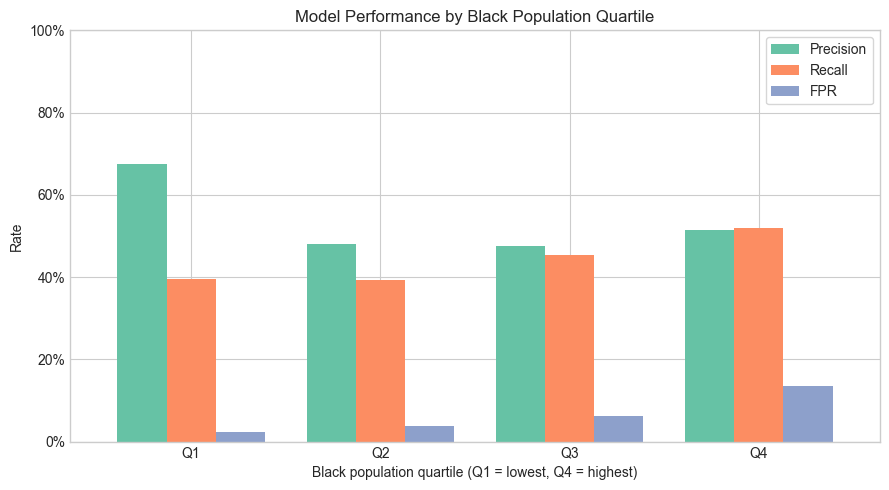

In [4]:
plt.style.use('seaborn-v0_8-whitegrid')

test_df = X_test.copy()
test_df['actual']      = y_test.values
test_df['predicted']   = y_pred_full
test_df['CensusTract'] = ct_test.values

# rank(method='first') breaks tied zero-values so qcut always produces 4 distinct bins
test_df['q_black'] = pd.qcut(
    X_test['pct_nhblack10'].rank(method='first'), q=4, labels=['Q1','Q2','Q3','Q4']
)

def quartile_metrics(frame, quartile_col):
    rows = []
    for quartile, group in frame.groupby(quartile_col, observed=False):
        tn, fp, fn, tp = confusion_matrix(group['actual'], group['predicted'], labels=[0, 1]).ravel()
        fpr = fp / (fp + tn) if (fp + tn) else np.nan
        rows.append({
            'quartile':           quartile,
            'n':                  len(group),
            'precision':          precision_score(group['actual'], group['predicted'], zero_division=0),
            'recall':             recall_score(group['actual'], group['predicted'], zero_division=0),
            'f1':                 f1_score(group['actual'], group['predicted'], zero_division=0),
            'false_positive_rate': fpr
        })
    return pd.DataFrame(rows)

black_quartile_metrics = quartile_metrics(test_df, 'q_black')
print(black_quartile_metrics.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = black_quartile_metrics.set_index('quartile')[['precision', 'recall', 'false_positive_rate']]
colors  = plt.get_cmap('Set2').colors[:3]
plot_df.plot(kind='bar', ax=ax, color=colors, width=0.78)
ax.set_title('Model Performance by Black Population Quartile')
ax.set_xlabel('Black population quartile (Q1 = lowest, Q4 = highest)')
ax.set_ylabel('Rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.legend(['Precision', 'Recall', 'FPR'], frameon=True)
ax.set_ylim(0, max(1.0, plot_df.max().max() * 1.15))
plt.xticks(rotation=0)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/05_quartile_black.png', dpi=200, bbox_inches='tight')
plt.show()

## 4. Quartile Analysis — Percentage Hispanic Population

  quartile     n  precision  recall      f1  false_positive_rate
0       Q1  3627     0.5381  0.4262  0.4756               0.0559
1       Q2  3627     0.5584  0.5798  0.5689               0.0641
2       Q3  3626     0.4636  0.5466  0.5017               0.0802
3       Q4  3627     0.5437  0.3200  0.4029               0.0455


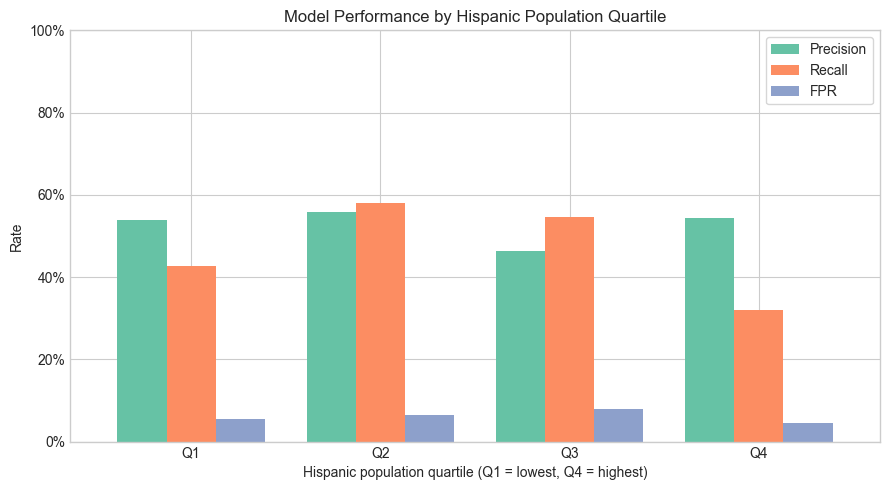

In [5]:
test_df['q_hisp'] = pd.qcut(
    X_test['pct_hisp10'].rank(method='first'), q=4, labels=['Q1','Q2','Q3','Q4']
)

hisp_quartile_metrics = quartile_metrics(test_df, 'q_hisp')
print(hisp_quartile_metrics.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = hisp_quartile_metrics.set_index('quartile')[['precision', 'recall', 'false_positive_rate']]
colors  = plt.get_cmap('Set2').colors[:3]
plot_df.plot(kind='bar', ax=ax, color=colors, width=0.78)
ax.set_title('Model Performance by Hispanic Population Quartile')
ax.set_xlabel('Hispanic population quartile (Q1 = lowest, Q4 = highest)')
ax.set_ylabel('Rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.legend(['Precision', 'Recall', 'FPR'], frameon=True)
ax.set_ylim(0, max(1.0, plot_df.max().max() * 1.15))
plt.xticks(rotation=0)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/05_quartile_hispanic.png', dpi=200, bbox_inches='tight')
plt.show()

## 5. Counterfactual Probe

In [6]:
food_desert_mask = y_pred_full == 1
national_black_median = X_test['pct_nhblack10'].median()
national_hisp_median = X_test['pct_hisp10'].median()

X_counterfactual = X_test.copy()
X_counterfactual.loc[food_desert_mask, 'pct_nhblack10'] = national_black_median
X_counterfactual.loc[food_desert_mask, 'pct_hisp10']    = national_hisp_median

X_cf_scaled = scaler.transform(X_counterfactual)
y_cf = rf.predict(X_cf_scaled)

total_food_desert_predictions = int(food_desert_mask.sum())
flipped = int(((y_pred_full == 1) & (y_cf == 0)).sum())
flip_rate = flipped / total_food_desert_predictions if total_food_desert_predictions else 0.0

print(f'Food desert predictions: {total_food_desert_predictions}')
print(f'Predictions that flip when race features set to median: {flipped} ({flip_rate:.1%})')
print('Interpretation: A higher flip rate means race features have stronger direct influence on positive predictions, even after other tract features remain unchanged.')

Food desert predictions: 1633
Predictions that flip when race features set to median: 549 (33.6%)
Interpretation: A higher flip rate means race features have stronger direct influence on positive predictions, even after other tract features remain unchanged.


## 6. HOLC Post-Prediction Audit

Tracts with HOLC grades in audit: 16421 (out of 72531 total)
            N tracts  Predicted FD rate  Actual FD rate
holc_grade                                             
A               1171              0.108           0.038
B               3341              0.180           0.069
C               7361              0.242           0.094
D               4548              0.274           0.137
C/D prediction rate: 0.254  |  A/B prediction rate: 0.162
Odds ratio (C+D vs A+B): 1.57x


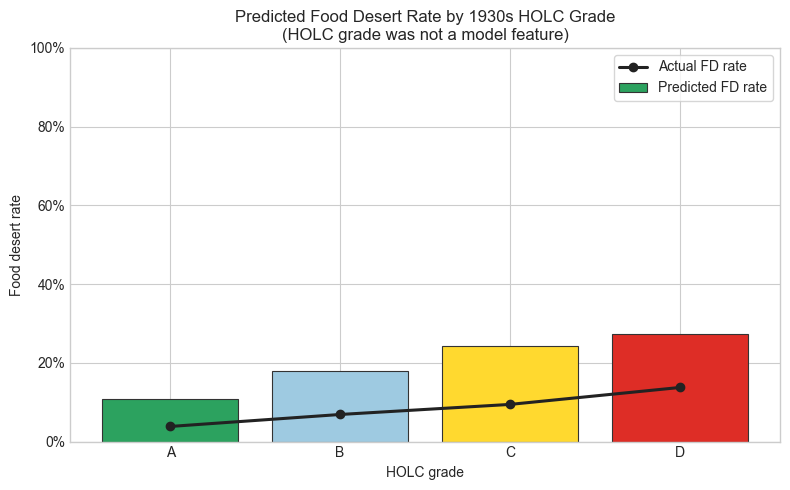

In [7]:
preds_df = pd.read_parquet(PRED_PATH)
holc_df = pd.read_csv(HOLC_PATH)
holc_df = holc_df[holc_df['holc_grade'].isin(['A', 'B', 'C', 'D'])].copy()

audit_df = preds_df.merge(holc_df, on='CensusTract', how='inner')
print(f'Tracts with HOLC grades in audit: {len(audit_df)} (out of 72531 total)')

holc_summary = (
    audit_df.groupby('holc_grade')
    .agg(
        n_tracts=('CensusTract', 'size'),
        pred_rate=('predicted_label', 'mean'),
        actual_rate=('LILATracts_1And10', 'mean')
    )
    .reindex(['A', 'B', 'C', 'D'])
)

print(
    holc_summary.rename(columns={
        'n_tracts': 'N tracts',
        'pred_rate': 'Predicted FD rate',
        'actual_rate': 'Actual FD rate'
    }).round(3)
)

cd_pred_rate = audit_df[audit_df['holc_grade'].isin(['C','D'])]['predicted_label'].mean()
ab_pred_rate = audit_df[audit_df['holc_grade'].isin(['A','B'])]['predicted_label'].mean()
odds_ratio = cd_pred_rate / ab_pred_rate
print(f'C/D prediction rate: {cd_pred_rate:.3f}  |  A/B prediction rate: {ab_pred_rate:.3f}')
print(f'Odds ratio (C+D vs A+B): {odds_ratio:.2f}x')

fig, ax = plt.subplots(figsize=(8, 5))
holc_colors = {'A': '#2ca25f', 'B': '#9ecae1', 'C': '#ffd92f', 'D': '#de2d26'}
grades = ['A', 'B', 'C', 'D']
ax.bar(
    grades,
    holc_summary.loc[grades, 'pred_rate'],
    color=[holc_colors[g] for g in grades],
    edgecolor='#333333',
    linewidth=0.8,
    label='Predicted FD rate'
)
ax.plot(
    grades,
    holc_summary.loc[grades, 'actual_rate'],
    color='#222222',
    marker='o',
    linewidth=2.2,
    label='Actual FD rate'
)
ax.set_title('Predicted Food Desert Rate by 1930s HOLC Grade\n(HOLC grade was not a model feature)')
ax.set_xlabel('HOLC grade')
ax.set_ylabel('Food desert rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.set_ylim(0, max(1.0, holc_summary[['pred_rate', 'actual_rate']].max().max() * 1.2))
ax.legend(frameon=True)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/05_holc_audit.png', dpi=200, bbox_inches='tight')
plt.show()

## Summary of Findings

The fairness audit surfaces three interlocking patterns that collectively demonstrate the model reproduces structural racial inequality — despite never receiving race as an explicit instruction.

**Race-removed model:** Removing percentage Black and Hispanic population reduces F1 from 0.489 to 0.467 (delta = -0.022) and ROC-AUC from 0.883 to 0.867. The modest but consistent drop across both metrics indicates that racial composition features carry predictive signal not fully encoded by income or poverty rate alone — the model cannot achieve equivalent performance on purely socioeconomic features.

**Quartile analysis — Black population:** The false positive rate rises monotonically from Q1 to Q4: 2.3% in the lowest-Black quartile versus 13.4% in the highest-Black quartile — a 5.9x disparity. The model is nearly six times more likely to falsely predict a food desert in a high-Black-population tract than in a comparable low-Black-population tract. This is not a function of actual food access conditions; it reflects the model having learned associations between racial composition and food insecurity status that exceed the ground truth signal.

**Counterfactual probe:** When percentage Black and Hispanic are replaced with their national median values in the 1,633 tracts predicted as food deserts, 549 predictions (33.6%) flip to non-food-desert. Holding all other tract characteristics constant, racial composition alone drives one-in-three positive predictions.

**HOLC post-prediction audit:** Tracts graded C or D by HOLC in the 1930s are 1.57 times more likely to be predicted food deserts today (25.4% prediction rate) than tracts graded A or B (16.2%). The gradient is monotonic: A = 10.8%, B = 18.0%, C = 24.2%, D = 27.4%. The model learned this pattern entirely from modern socioeconomic and demographic data — HOLC grade was never a training feature. This constitutes empirical evidence that contemporary food insecurity spatially reproduces historical discriminatory lending policy, and that a model trained exclusively on present-day census data will inherit and operationalize that inherited geography.

In [8]:
fairness_summary = {
    'full_model_f1':         float(full_metrics['f1']),
    'race_removed_f1':       float(nr_metrics['f1']),
    'f1_delta':              float(full_metrics['f1'] - nr_metrics['f1']),
    'holc_cd_pred_rate':     float(cd_pred_rate),
    'holc_ab_pred_rate':     float(ab_pred_rate),
    'holc_odds_ratio':       float(odds_ratio),
    'counterfactual_flip_rate': float(flip_rate)
}
with open('../outputs/fairness_metrics.json', 'w') as f:
    json.dump(fairness_summary, f, indent=2)
print("Saved outputs/fairness_metrics.json")
print(json.dumps(fairness_summary, indent=2))

Saved outputs/fairness_metrics.json
{
  "full_model_f1": 0.48911798396334477,
  "race_removed_f1": 0.467416906568961,
  "f1_delta": 0.02170107739438376,
  "holc_cd_pred_rate": 0.2540095725921572,
  "holc_ab_pred_rate": 0.16156914893617022,
  "holc_odds_ratio": 1.5721415521753266,
  "counterfactual_flip_rate": 0.33619105939987753
}
